# Import libraray

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set(style='whitegrid',palette='Set2',font_scale=1.1)
pd.set_option("display.float_format","{:2f}".format)

# Import Dataset

In [3]:
df = pd.read_csv("../01_data/spam.csv",encoding="latin1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

# Data Cleaning

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [6]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

Observation : Most of values missing in columns 'Unnamed: 2' , 'Unnamed: 3', 'Unnamed: 4'           
So we Drop the columns


In [7]:
# drop last 3 columns
df.drop(columns = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],inplace = True)

Columns names are not Description       
rename the columns 

In [8]:
df.rename(columns= {
    'v1': 'target',
    'v2': 'text'
},inplace = True)

In [9]:
df.sample(5)

,target,text
3060,ham,What u talking bout early morning? It's almost...
3336,ham,I AM AT THE GAS STATION. GO THERE.
2023,ham,Is there any movie theatre i can go to and wat...
2712,ham,Hey you still want to go for yogasana? Coz if ...
4238,ham,"Sez, hows u & de arab boy? Hope u r all good g..."


Using label Encoding  Convert Categorical target --> Numbers      

In [10]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoder.fit_transform(df['target'])

array([0, 0, 1, ..., 0, 0, 0], shape=(5572,))

In [11]:
df['target'] = encoder.fit_transform(df['target'])

In [12]:
df.sample(5)

,target,text
2288,0,Dont you have message offer
3512,0,Staff of placement training in Amrita college.
2543,0,Package all your programs well
2150,0,"The table's occupied, I'm waiting by the tree"
126,0,"Just so that you know,yetunde hasn't sent mone..."


In [13]:
# check missing values
df.isna().sum()

target    0
text      0
dtype: int64

In [14]:
# check duplicate values 
df.duplicated().sum()

np.int64(403)

In [15]:
# remove duplicates
df.drop_duplicates(keep='first',inplace=True)

In [16]:
df

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [17]:
df.shape

(5169, 2)

# EDA

Q : How much percentage message are spam or not spam 

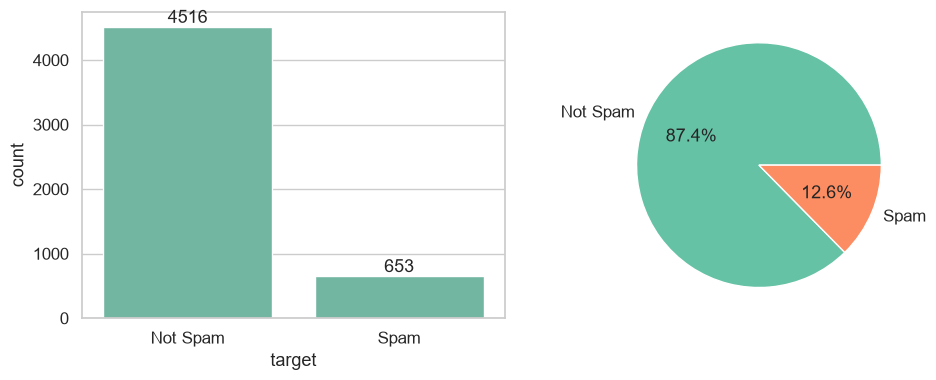

In [23]:
data = df["target"].replace({0: "Not Spam", 1: "Spam", "ham": "Not Spam"})
counts = data.value_counts()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Bar plot with auto-numbers
sns.countplot(x=data, order=["Not Spam", "Spam"], ax=ax[0])
ax[0].bar_label(ax[0].containers[0])

ax[1].pie(
    [counts["Not Spam"], counts["Spam"]],
    labels=["Not Spam", "Spam"],
    autopct="%.1f%%",
)
plt.tight_layout()
plt.show()

Observation : Data is imbalance 

Count the number of characters , words , sentences 

In [24]:
df['text'].apply(len)

0       111
1        29
2       155
3        49
4        61
       ... 
5567    161
5568     37
5569     57
5570    125
5571     26
Name: text, Length: 5169, dtype: int64

In [38]:
df['num_characters'] = df['text'].apply(len)

In [39]:
df

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161
5568,0,Will Ì_ b going to esplanade fr home?,37
5569,0,"Pity, * was in mood for that. So...any other s...",57
5570,0,The guy did some bitching but I acted like i'd...,125


In [27]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sumit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [30]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sumit\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [31]:
# number of words 
df['text'].apply((lambda x: nltk.word_tokenize(x)))

0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568     [Will, Ì_, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: text, Length: 5169, dtype: object

In [32]:
df['text'].apply((lambda x: len(nltk.word_tokenize(x))))

0       24
1        8
2       37
3       13
4       15
        ..
5567    35
5568     9
5569    15
5570    27
5571     7
Name: text, Length: 5169, dtype: int64

In [40]:
df['num_words'] = df['text'].apply((lambda x: len(nltk.word_tokenize(x))))

In [41]:
df

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35
5568,0,Will Ì_ b going to esplanade fr home?,37,9
5569,0,"Pity, * was in mood for that. So...any other s...",57,15
5570,0,The guy did some bitching but I acted like i'd...,125,27


In [43]:
# number of sentences
df['text'].apply(lambda x : nltk.sent_tokenize(x))

0       [Go until jurong point, crazy.., Available onl...
1                        [Ok lar..., Joking wif u oni...]
2       [Free entry in 2 a wkly comp to win FA Cup fin...
3       [U dun say so early hor... U c already then sa...
4       [Nah I don't think he goes to usf, he lives ar...
                              ...                        
5567    [This is the 2nd time we have tried 2 contact ...
5568              [Will Ì_ b going to esplanade fr home?]
5569    [Pity, * was in mood for that., So...any other...
5570    [The guy did some bitching but I acted like i'...
5571                        [Rofl., Its true to its name]
Name: text, Length: 5169, dtype: object

In [44]:
df['text'].apply(lambda x : len( nltk.sent_tokenize(x)))

0       2
1       2
2       2
3       1
4       1
       ..
5567    4
5568    1
5569    2
5570    1
5571    2
Name: text, Length: 5169, dtype: int64

In [45]:
df['num_sentences'] = df['text'].apply(lambda x : len( nltk.sent_tokenize(x)))

In [46]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [48]:
df.columns

Index(['target', 'text', 'num_characters', 'num_words', 'num_sentences'], dtype='str')

In [50]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.460437,1.965564
std,58.236293,13.334441,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
# analyise the spam and not spam messages indivually 

In [95]:
# ham
ham_df = df[df['target'] == 0]
ham_df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.128432,1.820195
std,56.358207,13.504730,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [94]:
# spam 
spam_df = df[df['target'] == 1]
spam_df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.672282,2.970904
std,30.137753,7.010932,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


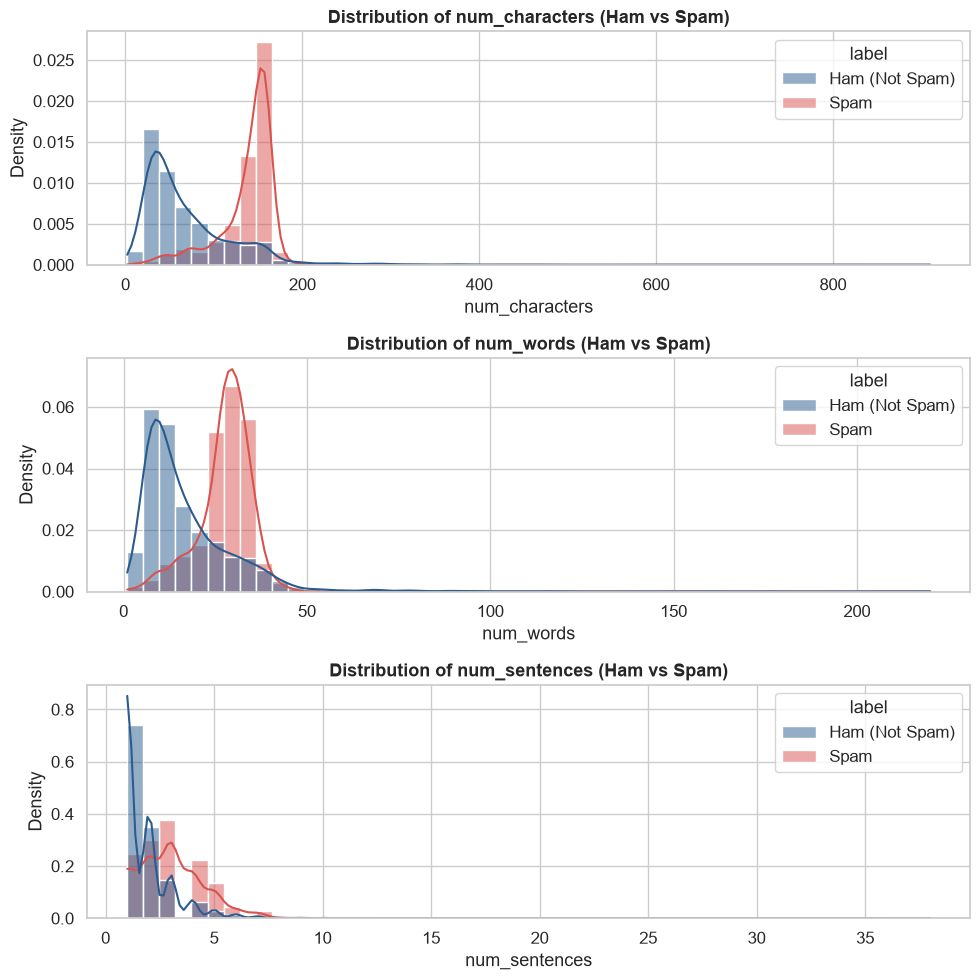

In [ ]:
numeric_col = ["num_characters", "num_words", "num_sentences"]

# Map 0 and 1 to readable names if not already mapped
df["label"] = df["target"].map({0: "Ham (Not Spam)", 1: "Spam"})

fig, axes = plt.subplots(3, 1, figsize=(10, 10))

for ax, col in zip(axes.ravel(), numeric_col):
    sns.histplot(
        data=df,
        x=col,
        hue="label",
        kde=True,
        ax=ax,
        palette={"Ham (Not Spam)": "#2b5c8f", "Spam": "#d9534f"},
        bins=50,
        stat="density",  # Normalizes counts so the smaller spam group isn't hidden
        common_norm=False,  # Allows each class KDE/distribution to scale independently
    )
    ax.set_title(f"Distribution of {col} (Ham vs Spam)", fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

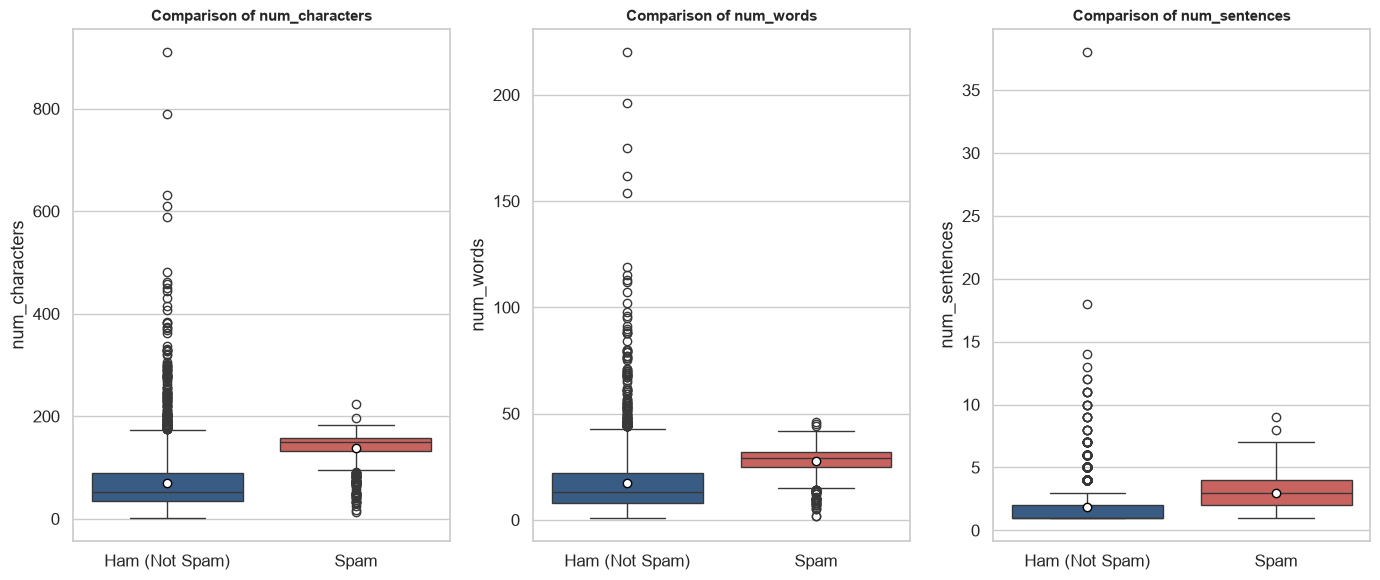

In [98]:
numeric_col = ["num_characters", "num_words", "num_sentences"]

# Map target to readable label names
df["label"] = df["target"].map({0: "Ham (Not Spam)", 1: "Spam"})

# Create 1 row, 3 columns of subplots for side-by-side boxplots
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

for ax, col in zip(axes.ravel(), numeric_col):
    sns.boxplot(
        data=df,
        x="label",
        y=col,
        hue="label",
        ax=ax,
        palette={"Ham (Not Spam)": "#2b5c8f", "Spam": "#d9534f"},
        showmeans=True,  # Shows the mean point inside each box
        meanprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
        },
    )
    ax.set_title(f"Comparison of {col}", fontweight="bold", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

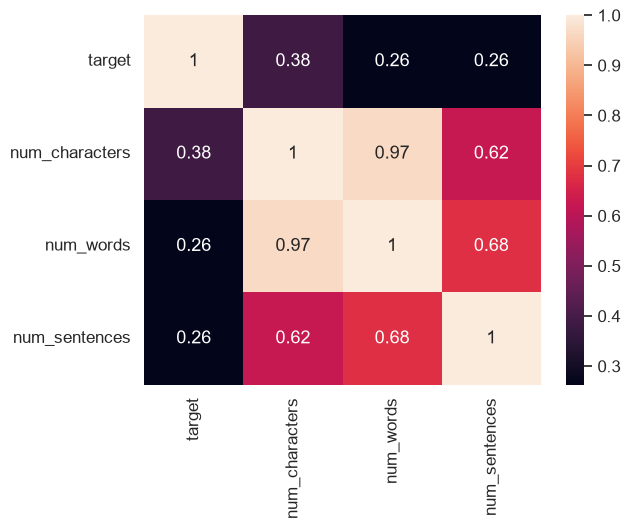

In [93]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

their is lots of multicollinairty in data . 
Meaning en 3 columns ma sa ek column choose karo ga
and num of character sabsa jada varience expalin kar raha ha target columns ka sath usko lo ga 

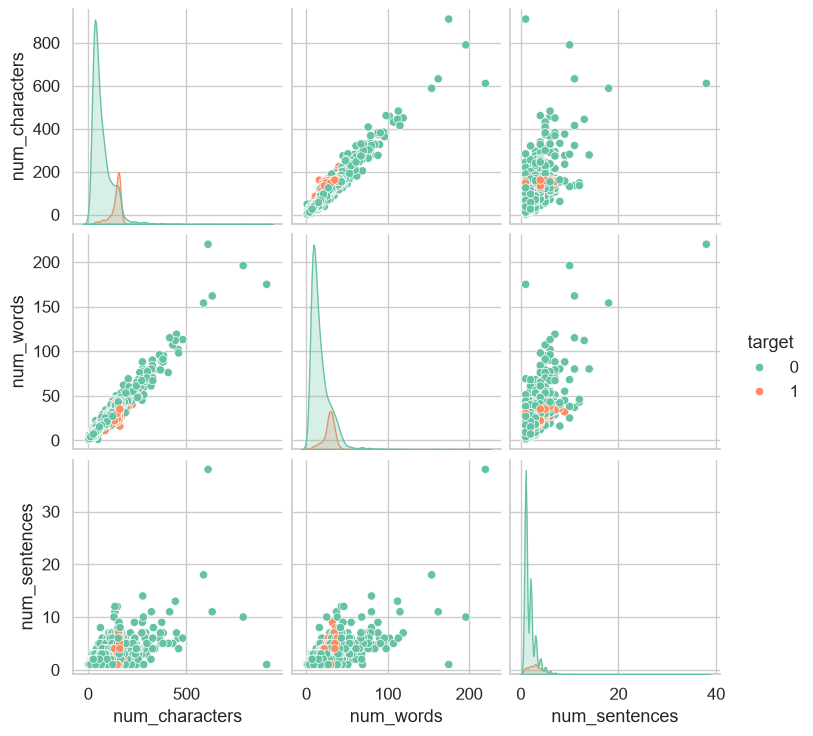

In [96]:
sns.pairplot(df,hue='target')